# DefectVision — Notebook 11
## End-to-End Inference Pipeline

This notebook turns the trained DefectVision model into a reusable inference system.

Input:
- any compatible RGB defect image

Output:
- predicted defect mask
- defect probability map
- predicted defect area
- predicted defect percentage
- confidence statistics
- four-panel visualization

No training is performed.


In [1]:

# ============================================================
# CELL 1 — SETUP
# ============================================================

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
torch.manual_seed(SEED)

DEVICE = torch.device("cpu")

ROOT = Path.cwd().resolve().parent

DATA = ROOT / "data" / "raw" / "MVTecAD-SEG"

CHECKPOINT = (
    ROOT
    / "models"
    / "checkpoints"
    / "model08_no_boundary_best.pth"
)

OUT = (
    ROOT
    / "results"
    / "inference"
)

OUT.mkdir(
    parents=True,
    exist_ok=True
)

IMAGE_SIZE = 256
THRESHOLD = 0.50

print("=" * 65)
print("DEFECTVISION — INFERENCE SYSTEM")
print("=" * 65)
print("Device:", DEVICE)
print("Checkpoint:", CHECKPOINT)
print("Checkpoint exists:", CHECKPOINT.exists())

assert CHECKPOINT.exists(), (
    "Final checkpoint not found."
)


DEFECTVISION — INFERENCE SYSTEM
Device: cpu
Checkpoint: C:\Documents\DefectVision\models\checkpoints\model08_no_boundary_best.pth
Checkpoint exists: True


In [2]:

# ============================================================
# CELL 2 — FINAL MODEL
# ============================================================

class ResidualBlock(nn.Module):

    def __init__(self, cin, cout):

        super().__init__()

        groups = min(8, cout)

        self.c1 = nn.Conv2d(
            cin, cout, 3,
            padding=1,
            bias=False
        )

        self.n1 = nn.GroupNorm(
            groups, cout
        )

        self.c2 = nn.Conv2d(
            cout, cout, 3,
            padding=1,
            bias=False
        )

        self.n2 = nn.GroupNorm(
            groups, cout
        )

        self.skip = (
            nn.Conv2d(
                cin, cout, 1,
                bias=False
            )
            if cin != cout
            else nn.Identity()
        )

    def forward(self, x):

        identity = self.skip(x)

        x = F.relu(
            self.n1(
                self.c1(x)
            )
        )

        x = self.n2(
            self.c2(x)
        )

        return F.relu(
            x + identity
        )


class MultiScaleBottleneck(nn.Module):

    def __init__(self, channels=64):

        super().__init__()

        b = channels // 4

        def branch(k, d):

            return nn.Sequential(
                nn.Conv2d(
                    channels,
                    b,
                    k,
                    padding=d if k == 3 else 0,
                    dilation=d,
                    bias=False
                ),
                nn.GroupNorm(4, b),
                nn.ReLU()
            )

        self.b1 = branch(1, 1)
        self.b2 = branch(3, 1)
        self.b3 = branch(3, 2)
        self.b4 = branch(3, 4)

        self.fuse = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                1,
                bias=False
            ),
            nn.GroupNorm(8, channels),
            nn.ReLU()
        )

    def forward(self, x):

        y = torch.cat(
            [
                self.b1(x),
                self.b2(x),
                self.b3(x),
                self.b4(x)
            ],
            dim=1
        )

        return self.fuse(y) + x


class DefectVisionModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.e1 = ResidualBlock(3, 16)
        self.d1 = nn.Conv2d(
            16, 16, 3, 2, 1
        )

        self.e2 = ResidualBlock(16, 32)
        self.d2 = nn.Conv2d(
            32, 32, 3, 2, 1
        )

        self.e3 = ResidualBlock(32, 48)
        self.d3 = nn.Conv2d(
            48, 48, 3, 2, 1
        )

        self.e4 = ResidualBlock(48, 64)
        self.d4 = nn.Conv2d(
            64, 64, 3, 2, 1
        )

        self.b = MultiScaleBottleneck(64)

        self.x4 = ResidualBlock(128, 48)
        self.x3 = ResidualBlock(96, 32)
        self.x2 = ResidualBlock(64, 16)
        self.x1 = ResidualBlock(32, 16)

        self.ref = ResidualBlock(16, 8)
        self.out = nn.Conv2d(8, 1, 1)

    def up(self, x, target):

        return F.interpolate(
            x,
            size=target.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

    def forward(self, x):

        e1 = self.e1(x)
        e2 = self.e2(self.d1(e1))
        e3 = self.e3(self.d2(e2))
        e4 = self.e4(self.d3(e3))

        x = self.b(
            self.d4(e4)
        )

        x = self.x4(
            torch.cat(
                [self.up(x, e4), e4],
                dim=1
            )
        )

        x = self.x3(
            torch.cat(
                [self.up(x, e3), e3],
                dim=1
            )
        )

        x = self.x2(
            torch.cat(
                [self.up(x, e2), e2],
                dim=1
            )
        )

        x = self.x1(
            torch.cat(
                [self.up(x, e1), e1],
                dim=1
            )
        )

        return self.out(
            self.ref(x)
        )


model = DefectVisionModel().to(DEVICE)

checkpoint = torch.load(
    CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Model loaded successfully.")
print("Training checkpoint epoch:", checkpoint["epoch"])
print("Best validation Dice:", checkpoint["val_dice"])


Model loaded successfully.
Training checkpoint epoch: 8
Best validation Dice: 0.42699394


In [3]:

# ============================================================
# CELL 3 — REUSABLE INFERENCE FUNCTION
# ============================================================

def predict_defect(
    image_path,
    threshold=THRESHOLD,
    save_result=True
):
    """
    Run DefectVision inference on one RGB image.

    Returns a dictionary containing:
    - original image
    - probability map
    - binary defect mask
    - defect pixel count
    - defect percentage
    - mean defect probability
    - maximum defect probability
    """

    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image not found: {image_path}"
        )

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    original = Image.open(
        image_path
    ).convert("RGB")

    original_size = original.size

    resized = original.resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        Image.Resampling.BILINEAR
    )

    rgb = np.asarray(
        resized,
        dtype=np.float32
    ) / 255.0

    # --------------------------------------------------------
    # Normalize exactly as during training
    # --------------------------------------------------------

    mean = np.array(
        [0.485, 0.456, 0.406],
        dtype=np.float32
    ).reshape(1, 1, 3)

    std = np.array(
        [0.229, 0.224, 0.225],
        dtype=np.float32
    ).reshape(1, 1, 3)

    normalized = (
        rgb - mean
    ) / std

    tensor = torch.from_numpy(
        normalized
    ).permute(
        2, 0, 1
    ).unsqueeze(0).float()

    # --------------------------------------------------------
    # Inference
    # --------------------------------------------------------

    with torch.no_grad():

        logits = model(
            tensor.to(DEVICE)
        )

        probability = torch.sigmoid(
            logits
        )[0, 0].cpu().numpy()

    # --------------------------------------------------------
    # Binary mask
    # --------------------------------------------------------

    mask = (
        probability >= threshold
    ).astype(np.uint8)

    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------

    defect_pixels = int(
        mask.sum()
    )

    total_pixels = int(
        mask.size
    )

    defect_percentage = (
        defect_pixels
        / total_pixels
        * 100
    )

    defect_probabilities = (
        probability[mask == 1]
    )

    if len(defect_probabilities) > 0:

        mean_defect_probability = float(
            defect_probabilities.mean()
        )

    else:

        mean_defect_probability = 0.0

    max_probability = float(
        probability.max()
    )

    # --------------------------------------------------------
    # Result dictionary
    # --------------------------------------------------------

    result = {

        "image_path":
            str(image_path),

        "original_width":
            original_size[0],

        "original_height":
            original_size[1],

        "model_input_size":
            IMAGE_SIZE,

        "threshold":
            threshold,

        "defect_detected":
            bool(defect_pixels > 0),

        "defect_pixels":
            defect_pixels,

        "total_pixels":
            total_pixels,

        "defect_percentage":
            defect_percentage,

        "mean_defect_probability":
            mean_defect_probability,

        "max_probability":
            max_probability,

        "rgb":
            rgb,

        "probability":
            probability,

        "mask":
            mask
    }

    # --------------------------------------------------------
    # Save JSON-compatible statistics
    # --------------------------------------------------------

    if save_result:

        stats = {
            k: v
            for k, v in result.items()
            if k not in [
                "rgb",
                "probability",
                "mask"
            ]
        }

        output_json = (
            OUT
            / f"{image_path.stem}_prediction.json"
        )

        with open(
            output_json,
            "w"
        ) as f:

            json.dump(
                stats,
                f,
                indent=2
            )

    return result


print(
    "Inference function ready."
)


Inference function ready.


## 4. Test the inference system on a real test image

This first test uses one of the actual MVTec test images.

Later, replace `IMAGE_PATH` with any compatible image on your computer.


In [5]:
# ============================================================
# CELL 4 — RUN INFERENCE
# ============================================================

from pathlib import Path

# Recreate dataset path
ROOT = Path.cwd().resolve().parent

DATA = (
    ROOT
    / "data"
    / "raw"
    / "MVTecAD-SEG"
)

IMG = DATA / "imgs"

# Test image
IMAGE_PATH = (
    IMG
    / "test"
    / "977.png"
)

print("Image:", IMAGE_PATH)
print("Exists:", IMAGE_PATH.exists())

assert IMAGE_PATH.exists(), (
    f"Test image not found: {IMAGE_PATH}"
)

# Run inference
result = predict_defect(
    IMAGE_PATH,
    threshold=THRESHOLD,
    save_result=True
)

print("=" * 65)
print("DEFECTVISION PREDICTION")
print("=" * 65)

print(
    "Image:",
    result["image_path"]
)

print(
    "Defect detected:",
    result["defect_detected"]
)

print(
    "Defect pixels:",
    result["defect_pixels"]
)

print(
    "Defect percentage:",
    f"{result['defect_percentage']:.2f}%"
)

print(
    "Mean defect probability:",
    f"{result['mean_defect_probability']:.4f}"
)

print(
    "Maximum probability:",
    f"{result['max_probability']:.4f}"
)

Image: C:\Documents\DefectVision\data\raw\MVTecAD-SEG\imgs\test\977.png
Exists: True
DEFECTVISION PREDICTION
Image: C:\Documents\DefectVision\data\raw\MVTecAD-SEG\imgs\test\977.png
Defect detected: True
Defect pixels: 8122
Defect percentage: 12.39%
Mean defect probability: 0.8606
Maximum probability: 0.9897


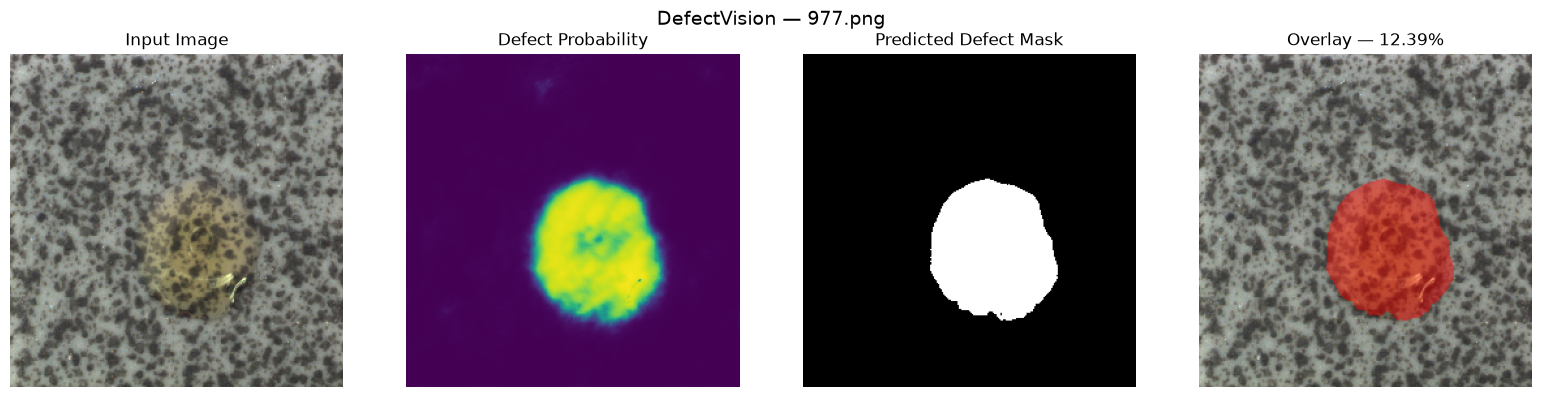

Saved visualization: C:\Documents\DefectVision\results\inference\977_inference.png


In [6]:

# ============================================================
# CELL 5 — VISUALIZE INFERENCE RESULT
# ============================================================

def visualize_prediction(
    result,
    save_name=None
):

    rgb = result["rgb"]
    probability = result["probability"]
    mask = result["mask"]

    overlay = rgb.copy()

    defect = mask.astype(bool)

    # Red overlay for predicted defect pixels.
    overlay[defect] = (
        0.55 * overlay[defect]
        + 0.45 * np.array(
            [1.0, 0.0, 0.0]
        )
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4)
    )

    axes[0].imshow(rgb)
    axes[0].set_title(
        "Input Image"
    )

    axes[1].imshow(
        probability,
        cmap="viridis",
        vmin=0,
        vmax=1
    )
    axes[1].set_title(
        "Defect Probability"
    )

    axes[2].imshow(
        mask,
        cmap="gray"
    )
    axes[2].set_title(
        "Predicted Defect Mask"
    )

    axes[3].imshow(
        overlay
    )
    axes[3].set_title(
        f"Overlay — {result['defect_percentage']:.2f}%"
    )

    for ax in axes:
        ax.axis("off")

    fig.suptitle(
        f"DefectVision — {Path(result['image_path']).name}",
        fontsize=14
    )

    plt.tight_layout()

    if save_name is None:

        save_name = (
            Path(
                result["image_path"]
            ).stem
            + "_inference.png"
        )

    save_path = (
        OUT / save_name
    )

    plt.savefig(
        save_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    return save_path


saved_path = visualize_prediction(
    result
)

print(
    "Saved visualization:",
    saved_path
)


## 6. Batch inference on multiple images

This demonstrates how the same inference function can process a collection of images without retraining.


In [7]:

# ============================================================
# CELL 6 — BATCH INFERENCE
# ============================================================

sample_paths = sorted(
    (IMG / "test").glob("*.png")
)[:10]

batch_results = []

for image_path in sample_paths:

    r = predict_defect(
        image_path,
        threshold=THRESHOLD,
        save_result=False
    )

    batch_results.append({

        "image":
            image_path.name,

        "defect_detected":
            r["defect_detected"],

        "defect_percentage":
            r["defect_percentage"],

        "mean_defect_probability":
            r["mean_defect_probability"],

        "max_probability":
            r["max_probability"]
    })


batch_df = (
    __import__("pandas")
    .DataFrame(batch_results)
)

display(batch_df)

batch_df.to_csv(
    OUT / "batch_inference_demo.csv",
    index=False
)

print(
    "Processed:",
    len(batch_df),
    "images"
)


,image,defect_detected,defect_percentage,mean_defect_probability,max_probability
0,1001.png,True,11.273193,0.864328,0.987725
1,1010.png,True,16.972351,0.688811,0.977594
2,1023.png,True,17.362976,0.751473,0.975507
3,1024.png,True,20.283508,0.739885,0.968452
4,1027.png,True,17.808533,0.770109,0.973332
5,1030.png,True,25.260925,0.784809,0.944622
6,1032.png,True,25.711060,0.772896,0.966541
7,1035.png,True,25.744629,0.763793,0.947472
8,1036.png,True,25.033569,0.786181,0.946111
9,104.png,True,26.290894,0.720659,0.979338


Processed: 10 images


## 7. Custom-image inference

For the final project demo, change `CUSTOM_IMAGE_PATH` to a real image path.

Example:

`C:/Documents/DefectVision/my_test_image.png`

The image should be an RGB image visually compatible with the training domain.


CUSTOM IMAGE RESULT
Defect detected: True
Predicted defect percentage: 7.62%
Mean defect probability: 0.8389
Maximum probability: 0.9997


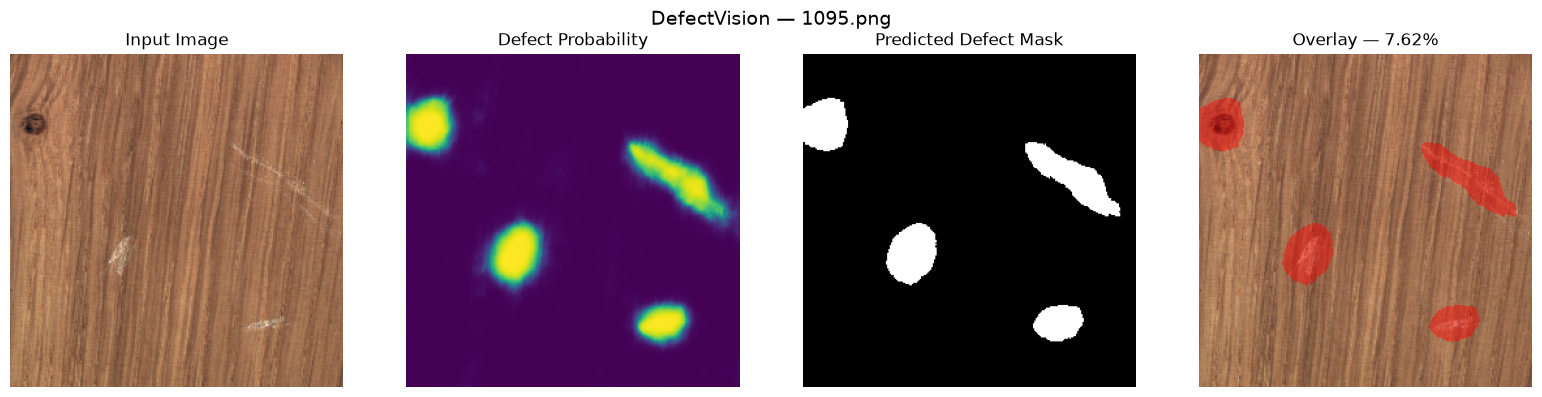

WindowsPath('C:/Documents/DefectVision/results/inference/custom_image_prediction.png')

In [8]:

# ============================================================
# CELL 7 — CUSTOM IMAGE
# ============================================================

CUSTOM_IMAGE_PATH = (
    IMG
    / "test"
    / "1095.png"
)

custom_result = predict_defect(
    CUSTOM_IMAGE_PATH,
    threshold=THRESHOLD,
    save_result=True
)

print("=" * 65)
print("CUSTOM IMAGE RESULT")
print("=" * 65)

print(
    "Defect detected:",
    custom_result["defect_detected"]
)

print(
    "Predicted defect percentage:",
    f"{custom_result['defect_percentage']:.2f}%"
)

print(
    "Mean defect probability:",
    f"{custom_result['mean_defect_probability']:.4f}"
)

print(
    "Maximum probability:",
    f"{custom_result['max_probability']:.4f}"
)

visualize_prediction(
    custom_result,
    save_name="custom_image_prediction.png"
)


In [9]:

# ============================================================
# CELL 8 — FINAL SYSTEM SUMMARY
# ============================================================

print("=" * 70)
print("DEFECTVISION INFERENCE SYSTEM READY")
print("=" * 70)

print()
print("Model:")
print("  MS-Residual U-Net")

print()
print("Loss:")
print("  Weighted BCE + Dice")

print()
print("Inference threshold:")
print(f"  {THRESHOLD}")

print()
print("Held-out test performance:")
print("  Dice      : 0.3753")
print("  IoU       : 0.2758")
print("  Precision : 0.3484")
print("  Recall    : 0.6988")

print()
print("Inference output:")
print("  • defect / no-defect indication")
print("  • pixel-level defect mask")
print("  • defect percentage")
print("  • probability map")
print("  • visual overlay")

print()
print("Results saved to:")
print(OUT)

print()
print("NOTEBOOK 11 COMPLETE")


DEFECTVISION INFERENCE SYSTEM READY

Model:
  MS-Residual U-Net

Loss:
  Weighted BCE + Dice

Inference threshold:
  0.5

Held-out test performance:
  Dice      : 0.3753
  IoU       : 0.2758
  Precision : 0.3484
  Recall    : 0.6988

Inference output:
  • defect / no-defect indication
  • pixel-level defect mask
  • defect percentage
  • probability map
  • visual overlay

Results saved to:
C:\Documents\DefectVision\results\inference

NOTEBOOK 11 COMPLETE
